# Tester_branch에서 최종 모델 성능 확인 진행

In [1]:
# 라이브러리 및 데이터 불러오기

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from sklearn.datasets import load_wine

from sklearn.model_selection import train_test_split, GridSearchCV

import matplotlib.pyplot as plt

wine = load_wine()

df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier


# feature로 사용할 데이터에서는 'target' 컬럼을 drop합니다.
# target은 'target' 컬럼만을 대상으로 합니다.
# X, y 데이터를 test size는 0.2, random_state 값은 42로 하여 train 데이터와 test 데이터로 분할합니다.

# DT 모델링 성능

Best Hyper-parameter {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Score 0.9224137931034484


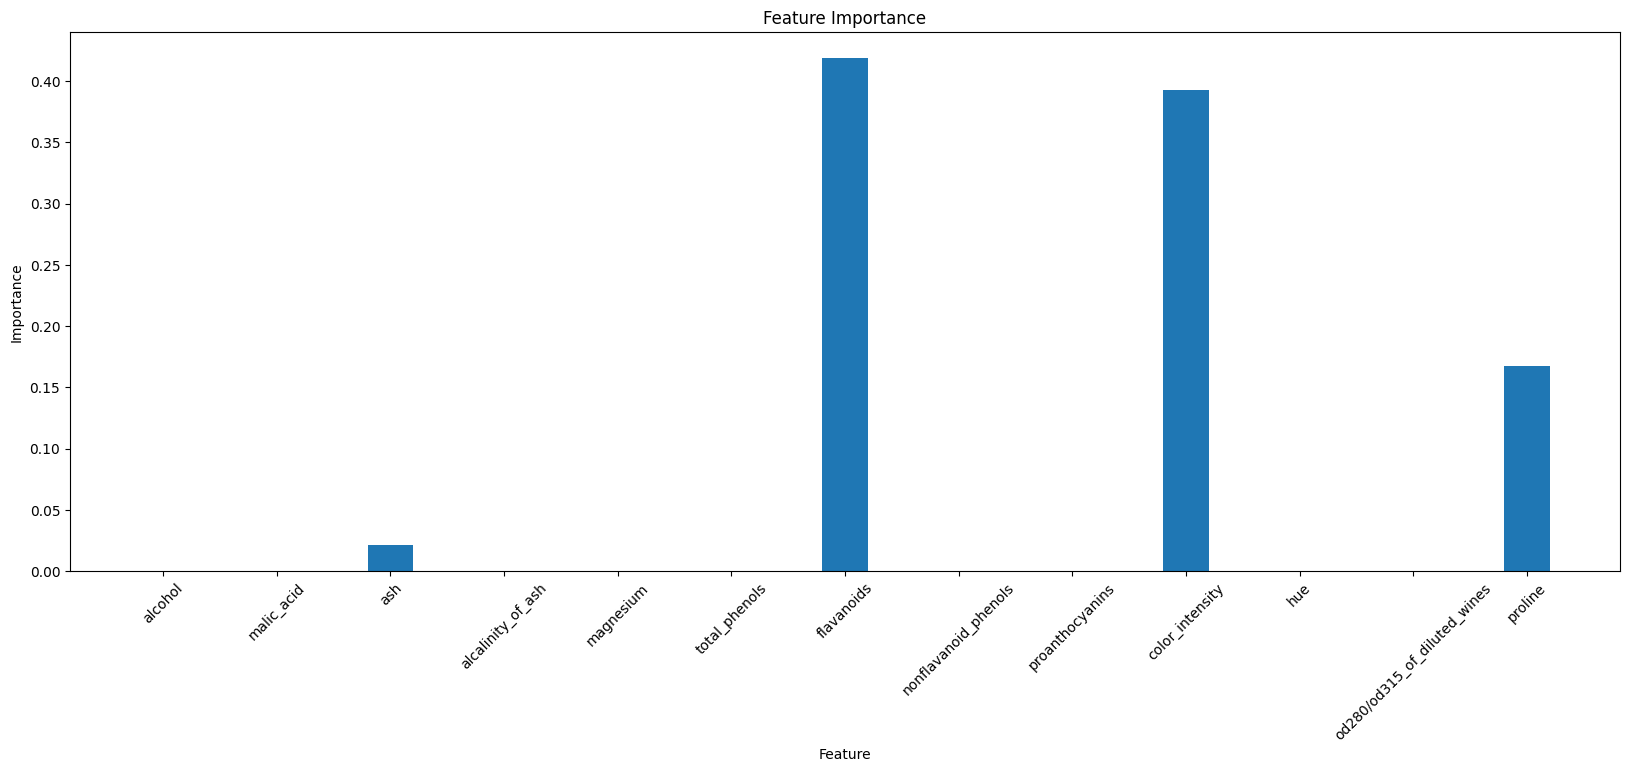

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import pandas as pd


dt_params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5],
    'min_samples_leaf': [1, 2, 3],
    'min_samples_split': [2, 3, 4]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=dt_params,
    cv=5
)

dt_grid.fit(X_train, y_train)

print('Best Hyper-parameter', dt_grid.best_params_)
print('Best Score', dt_grid.best_score_)

dt_best_model = dt_grid.best_estimator_

plt.figure(figsize=(20, 7))
plt.bar(X.columns, dt_best_model.feature_importances_, width=0.4)
plt.title('Feature Importance')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.show()

<img src="../참고이미지/Git/DT_Modeling.png" width="80%">

# XGB 모델링 성능

Best Hyper-parameter {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best Score 0.9645320197044336


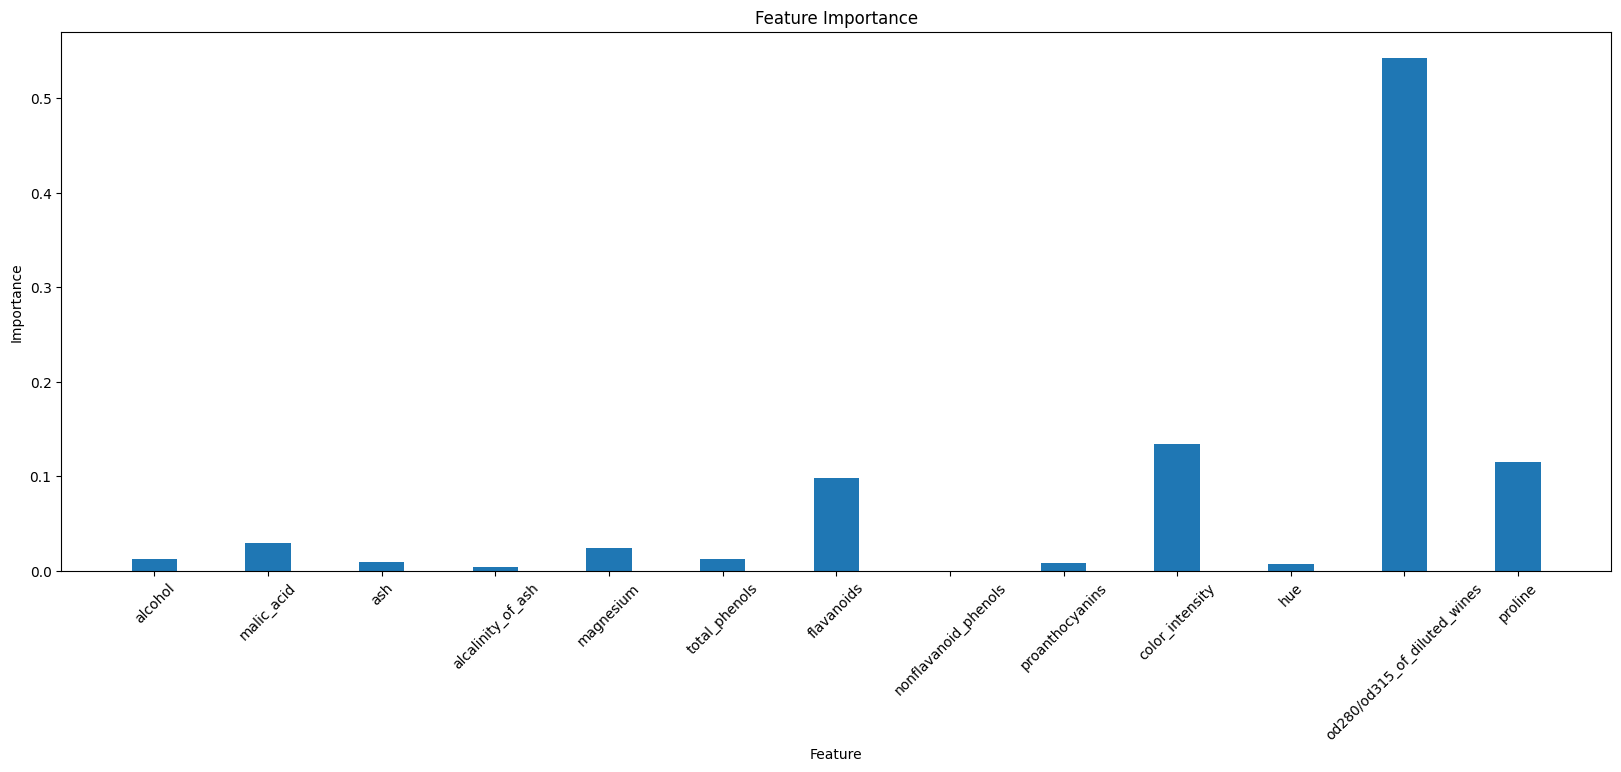

In [17]:
from xgboost import XGBClassifier

xgb_params = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [50, 100]
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss'),
    param_grid=xgb_params,
    cv=5
)

xgb_grid.fit(X_train, y_train)

print('Best Hyper-parameter', xgb_grid.best_params_)
print('Best Score', xgb_grid.best_score_)

xgb_best_model = xgb_grid.best_estimator_

plt.figure(figsize=(20, 7))
plt.bar(X.columns, xgb_best_model.feature_importances_,width=0.4)
plt.title('Feature Importance')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.show()

<img src="../참고이미지/Git/XGB_Modeling.png" width="80%">`

# 성능 비교 시각화

============== DT 성능 확인 ==============
DT accuracy : 0.9444444444444444
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.88      1.00      0.93        14
           2       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.96      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36

============== XGB 성능 확인 ==============
XGB accuracy : 0.9722222222222222
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.93      1.00      0.97        14
           2       1.00      0.88      0.93         8

    accuracy                           0.97        36
   macro avg       0.98      0.96      0.97        36
weighted avg       0.97      0.97      0.97        36



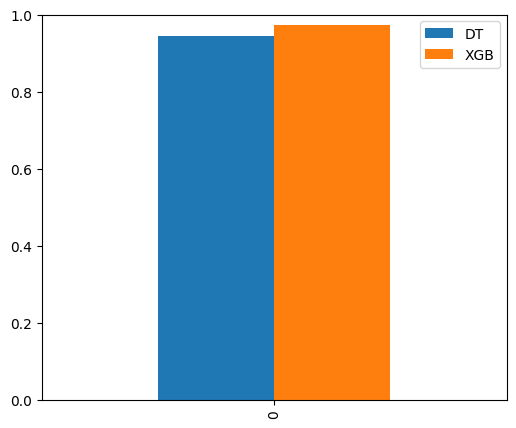

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

print("============== DT 성능 확인 ==============")
dt_pred = dt_best_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)
print("DT accuracy :", dt_accuracy)
print(classification_report(y_test, dt_pred))

print("============== XGB 성능 확인 ==============")
xgb_pred = xgb_best_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_pred)
print("XGB accuracy :", xgb_accuracy)
print(classification_report(y_test, xgb_pred))


score_df = pd.DataFrame({
    'DT': [dt_accuracy],
    'XGB': [xgb_accuracy]
})

score_df.plot(kind='bar', figsize=(6, 5))

plt.ylim(0, 1)
plt.show()

<img src="../참고이미지/Git/성능_비교_시각화.png" width="40%">